# Previous-newline score and competitor margin by count and line width

For every content-token query with an actual preceding `_NEWLINE_`, this notebook measures two quantities for a configurable attention head:

1. **Previous-newline paired QK inner product:** `q_query · k_previous_newline / sqrt(d_head)`, computed directly from the cached Q/K vectors and checked against the cached pre-softmax attention score.
2. **Competitor-relative margin:** `newline_score - logsumexp(all other causal key scores)`. This is the log-odds of attending to that newline rather than any competing key, so `sigmoid(margin)` must equal the head's attention probability on that newline.

Both quantities are averaged jointly by `(current character count, sampled line width)` and separately by `character count - line width`. Newline-token queries have character count 0 and are paired with the preceding newline; queries before the first real newline are excluded.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
from IPython.display import display

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
LAYER = 2
HEAD = 3
N_SEQUENCES = 5_000
BATCH_SIZE = 128
DATA_SEED = 16_001

In [2]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH, model=model, map_location=device
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
seq_len = cfg["task"]["seq_len"]
if not 0 <= LAYER < n_layers:
    raise ValueError(f"LAYER must be in [0, {n_layers - 1}].")
if not 0 <= HEAD < n_heads:
    raise ValueError(f"HEAD must be in [0, {n_heads - 1}].")

min_line_width, max_line_width = project_data.get_line_length_range(cfg["task"])
max_token_length = cfg["task"]["num_token_lengths"]
max_character_count = max_line_width + max_token_length - 1
LINE_WIDTH_VALUES = np.arange(min_line_width, max_line_width + 1)
CHARACTER_COUNT_VALUES = np.arange(0, max_character_count + 1)
DELTA_VALUES = np.arange(-max_line_width, max_token_length)
SCORE_SITE = f"blocks.{LAYER}.attn.hook_attn_scores"
QUERY_SITE = f"blocks.{LAYER}.attn.hook_q"
KEY_SITE = f"blocks.{LAYER}.attn.hook_k"

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Attention head: layer {LAYER}, head {HEAD}")
print(f"Cached pre-softmax scores: {SCORE_SITE}")
print(f"Cached queries/keys: {QUERY_SITE}, {KEY_SITE}")
print(f"Character counts: 0 through {max_character_count}")
print(f"Line widths: {min_line_width} through {max_line_width}")
print(f"Count-minus-width values: {DELTA_VALUES[0]} through {DELTA_VALUES[-1]}")

Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Attention head: layer 2, head 3
Cached pre-softmax scores: blocks.2.attn.hook_attn_scores
Cached queries/keys: blocks.2.attn.hook_q, blocks.2.attn.hook_k
Character counts: 0 through 107
Line widths: 50 through 100
Count-minus-width values: -100 through 7


## Identify real query/previous-newline pairs

Character count includes the current content token. The stored key position is always the most recent newline strictly preceding the query.

In [3]:
def previous_newline_query_metadata(
    token_rows: torch.Tensor, line_widths: torch.Tensor
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    batch_indices = []
    query_indices = []
    newline_key_indices = []
    character_counts = []
    widths = []

    for batch_index, (token_row, line_width) in enumerate(zip(
        token_rows.detach().cpu().tolist(),
        line_widths.detach().cpu().tolist(),
    )):
        running_count = 0
        previous_newline_position = None
        for query_position, token_id in enumerate(token_row):
            if token_id == vocab.newline_id:
                if previous_newline_position is not None:
                    batch_indices.append(batch_index)
                    query_indices.append(query_position)
                    newline_key_indices.append(previous_newline_position)
                    character_counts.append(0)
                    widths.append(line_width)
                running_count = 0
                previous_newline_position = query_position
                continue

            running_count += project_data.extract_character_count(
                vocab.decode_token(token_id)
            )
            if previous_newline_position is None:
                continue

            batch_indices.append(batch_index)
            query_indices.append(query_position)
            newline_key_indices.append(previous_newline_position)
            character_counts.append(running_count)
            widths.append(line_width)

    return tuple(
        np.asarray(values, dtype=np.int64)
        for values in (
            batch_indices, query_indices, newline_key_indices,
            character_counts, widths,
        )
    )


## Aggregate the actual score and competitor margin

For every valid query, this computes the paired inner product `q_query · k_previous_newline / sqrt(d_head)` directly from the model's cached queries and keys. These vectors already include the effects of per-token LayerNorm and the learned Q/K biases. The cached attention score is used as an independent consistency check. For the competitor margin, the previous-newline key is removed before the competitor `logsumexp`.

In [4]:
@torch.no_grad()
def collect_score_and_margin_statistics(
    n_sequences: int, *, seed: int, batch_size: int = BATCH_SIZE
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    shape = (len(CHARACTER_COUNT_VALUES), len(LINE_WIDTH_VALUES))
    score_sums = np.zeros(shape, dtype=np.float64)
    margin_sums = np.zeros(shape, dtype=np.float64)
    examples = np.zeros(shape, dtype=np.int64)
    delta_score_sums = np.zeros(len(DELTA_VALUES), dtype=np.float64)
    delta_margin_sums = np.zeros(len(DELTA_VALUES), dtype=np.float64)
    delta_examples = np.zeros(len(DELTA_VALUES), dtype=np.int64)
    maximum_qk_score_error = 0.0
    maximum_probability_error = 0.0

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size, vocab=vocab, task_cfg=cfg["task"],
            device=device, seed=seed + start,
        )
        (
            batch_indices, query_indices, newline_key_indices,
            character_counts, line_widths,
        ) = previous_newline_query_metadata(batch.tokens, batch.line_lengths)
        if len(character_counts) == 0:
            continue

        _, cache = model.run_with_cache(
            batch.tokens, prepend_bos=False,
            names_filter=lambda name: name in {SCORE_SITE, QUERY_SITE, KEY_SITE},
        )
        scores = cache[SCORE_SITE][:, HEAD]
        queries = cache[QUERY_SITE][:, :, HEAD, :]
        keys = cache[KEY_SITE][:, :, HEAD, :]
        score_device = scores.device
        b = torch.as_tensor(batch_indices, device=score_device)
        q = torch.as_tensor(query_indices, device=score_device)
        k = torch.as_tensor(newline_key_indices, device=score_device)
        selected_rows = scores[b, q, :]
        cached_newline_scores = selected_rows.gather(1, k[:, None]).squeeze(1)
        newline_scores = (queries[b, q, :] * keys[b, k, :]).sum(dim=-1) / np.sqrt(
            cfg["model"]["d_head"]
        )
        qk_score_error = (newline_scores - cached_newline_scores).abs().max().item()
        maximum_qk_score_error = max(maximum_qk_score_error, qk_score_error)

        key_positions = torch.arange(seq_len, device=score_device)[None, :]
        competitor_mask = (key_positions <= q[:, None]) & (
            key_positions != k[:, None]
        )
        competitor_logsumexp = torch.logsumexp(
            selected_rows.masked_fill(~competitor_mask, -torch.inf), dim=1
        )
        margins = newline_scores - competitor_logsumexp

        # The margin is exactly the log-odds for this key under softmax.
        newline_probabilities = torch.softmax(selected_rows, dim=1).gather(
            1, k[:, None]
        ).squeeze(1)
        probability_error = (
            torch.sigmoid(margins) - newline_probabilities
        ).abs().max().item()
        maximum_probability_error = max(
            maximum_probability_error, probability_error
        )

        newline_scores_np = newline_scores.detach().cpu().double().numpy()
        margins_np = margins.detach().cpu().double().numpy()
        count_indices = character_counts - CHARACTER_COUNT_VALUES[0]
        width_indices = line_widths - LINE_WIDTH_VALUES[0]
        np.add.at(score_sums, (count_indices, width_indices), newline_scores_np)
        np.add.at(margin_sums, (count_indices, width_indices), margins_np)
        np.add.at(examples, (count_indices, width_indices), 1)

        deltas = character_counts - line_widths
        delta_indices = deltas - DELTA_VALUES[0]
        np.add.at(delta_score_sums, delta_indices, newline_scores_np)
        np.add.at(delta_margin_sums, delta_indices, margins_np)
        np.add.at(delta_examples, delta_indices, 1)

    observed = examples > 0
    mean_scores = np.full(shape, np.nan)
    mean_margins = np.full(shape, np.nan)
    mean_scores[observed] = score_sums[observed] / examples[observed]
    mean_margins[observed] = margin_sums[observed] / examples[observed]

    delta_observed = delta_examples > 0
    mean_delta_scores = np.full(len(DELTA_VALUES), np.nan)
    mean_delta_margins = np.full(len(DELTA_VALUES), np.nan)
    mean_delta_scores[delta_observed] = (
        delta_score_sums[delta_observed] / delta_examples[delta_observed]
    )
    mean_delta_margins[delta_observed] = (
        delta_margin_sums[delta_observed] / delta_examples[delta_observed]
    )

    print(f"Valid query/newline pairs: {examples.sum():,}")
    print(f"Observed joint bins: {observed.sum():,} / {observed.size:,}")
    print(
        "Maximum |explicit q·k/sqrt(d_head) - cached attention score|: "
        f"{maximum_qk_score_error:.3e}"
    )
    print(
        "Maximum |sigmoid(margin) - cached-score softmax probability|: "
        f"{maximum_probability_error:.3e}"
    )
    return (
        mean_scores, mean_margins, examples,
        mean_delta_scores, mean_delta_margins, delta_examples,
    )


(
    mean_newline_score, mean_competitor_margin, examples_by_count_and_width,
    mean_score_by_delta, mean_margin_by_delta, examples_by_delta,
) = collect_score_and_margin_statistics(N_SEQUENCES, seed=DATA_SEED)

Valid query/newline pairs: 654,139
Observed joint bins: 4,233 / 5,508
Maximum |explicit q·k/sqrt(d_head) - cached attention score|: 7.629e-06
Maximum |sigmoid(margin) - cached-score softmax probability|: 1.967e-06


## Joint character-count × line-width heatmaps

The dotted diagonal is `character count = line width`; cells above it have crossed the boundary. Gray cells were not observed.

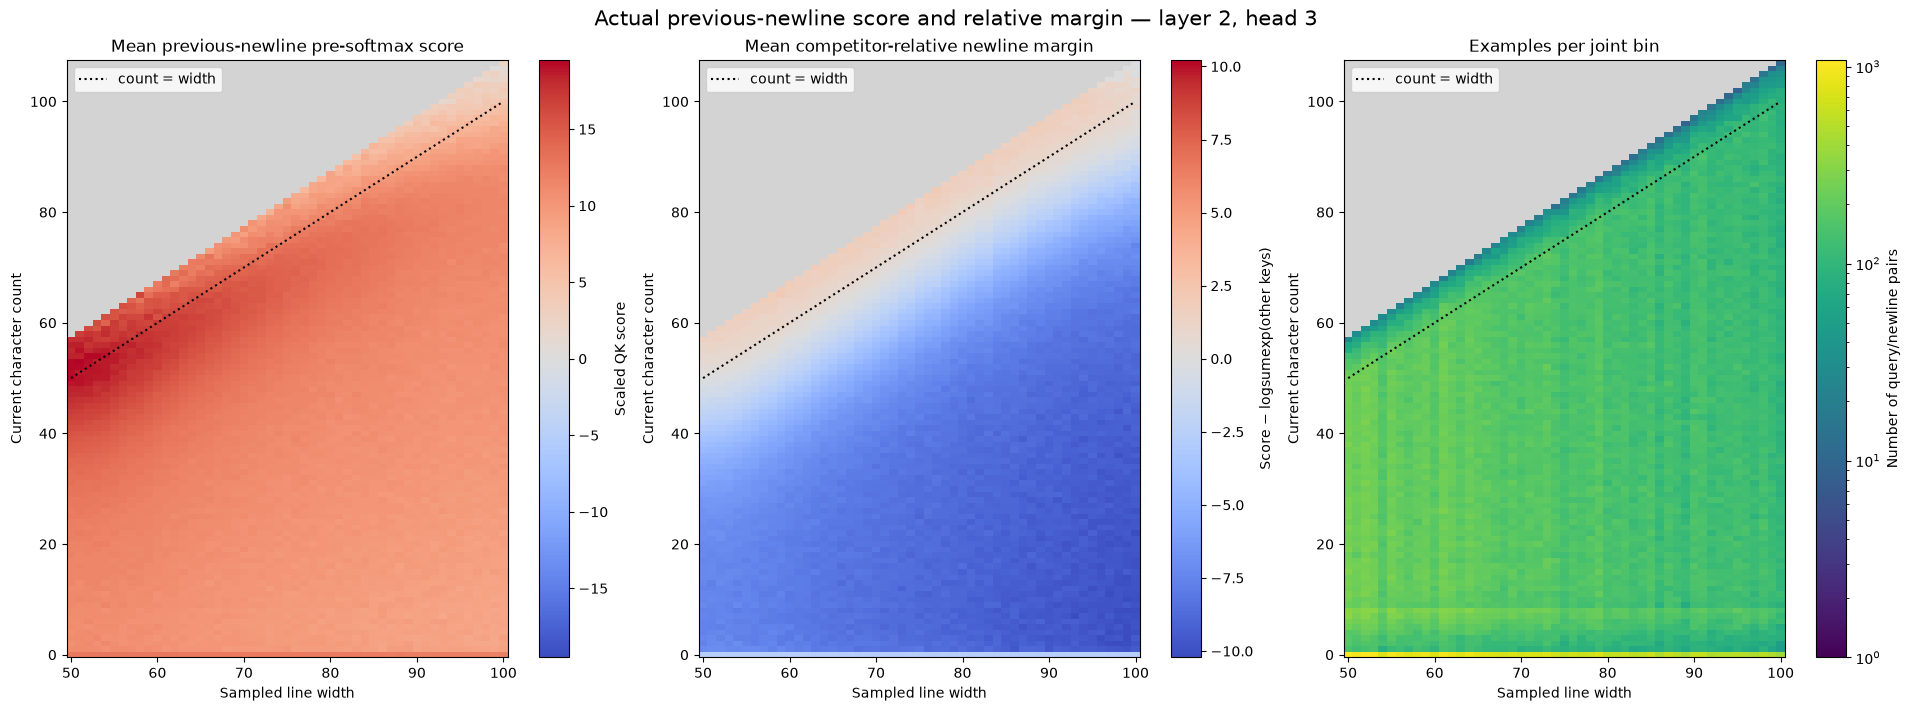

In [5]:
def symmetric_norm(values: np.ndarray) -> TwoSlopeNorm:
    limit = max(float(np.nanmax(np.abs(values))), 1e-12)
    return TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)


score_masked = np.ma.masked_invalid(mean_newline_score)
margin_masked = np.ma.masked_invalid(mean_competitor_margin)
count_masked = np.ma.masked_where(
    examples_by_count_and_width == 0, examples_by_count_and_width
)
diverging_cmap = plt.get_cmap("coolwarm").copy()
diverging_cmap.set_bad("lightgray")
count_cmap = plt.get_cmap("viridis").copy()
count_cmap.set_bad("lightgray")
extent = (
    min_line_width - 0.5, max_line_width + 0.5,
    -0.5, max_character_count + 0.5,
)

fig, axes = plt.subplots(1, 3, figsize=(19, 7), constrained_layout=True)
panels = [
    (score_masked, symmetric_norm(mean_newline_score), diverging_cmap,
     "Mean previous-newline pre-softmax score", "Scaled QK score"),
    (margin_masked, symmetric_norm(mean_competitor_margin), diverging_cmap,
     "Mean competitor-relative newline margin", "Score − logsumexp(other keys)"),
    (count_masked, LogNorm(vmin=1, vmax=examples_by_count_and_width.max()), count_cmap,
     "Examples per joint bin", "Number of query/newline pairs"),
]
for ax, (values, norm, cmap, title, colorbar_label) in zip(axes, panels):
    image = ax.imshow(
        values, origin="lower", aspect="auto", interpolation="nearest",
        extent=extent, norm=norm, cmap=cmap,
    )
    ax.plot(
        [min_line_width, max_line_width],
        [min_line_width, max_line_width],
        color="black", linestyle=":", linewidth=1.5,
        label="count = width",
    )
    ax.set_xlabel("Sampled line width")
    ax.set_ylabel("Current character count")
    ax.set_title(title)
    ax.legend(loc="upper left")
    fig.colorbar(image, ax=ax, label=colorbar_label)

fig.suptitle(
    f"Actual previous-newline score and relative margin — layer {LAYER}, head {HEAD}",
    fontsize=15,
)
plt.show()

# Interactive version of the full joint grid: hover for exact means and sample sizes.
interactive_limit = max(float(np.nanmax(np.abs(mean_newline_score))), 1e-12)
interactive_fig = go.Figure(
    data=go.Heatmap(
        x=LINE_WIDTH_VALUES,
        y=CHARACTER_COUNT_VALUES,
        z=mean_newline_score,
        customdata=examples_by_count_and_width,
        zmin=-interactive_limit,
        zmid=0.0,
        zmax=interactive_limit,
        colorscale="RdBu_r",
        colorbar=dict(title="Mean q·k/√d_head"),
        hovertemplate=(
            "line width=%{x}<br>"
            "character count=%{y}<br>"
            "mean paired QK inner product=%{z:.6f}<br>"
            "examples=%{customdata:,}<extra></extra>"
        ),
    )
)
interactive_fig.add_trace(
    go.Scatter(
        x=LINE_WIDTH_VALUES,
        y=LINE_WIDTH_VALUES,
        mode="lines",
        line=dict(color="black", dash="dot", width=1.5),
        name="count = width",
        hoverinfo="skip",
    )
)
interactive_fig.update_layout(
    title=(
        "Full joint-conditional mean paired QK inner product<br>"
        f"<sup>Layer {LAYER}, head {HEAD}; query to actual previous newline key</sup>"
    ),
    xaxis_title="Sampled line width",
    yaxis_title="Current character count",
    width=1050,
    height=800,
)
interactive_fig.show()

## Boundary-relative view

Here `count − width = 0` means the query exactly reaches the boundary; positive values are overshoots. This aggregation makes a threshold at the boundary directly visible.

,mean_newline_score,mean_competitor_margin,n_examples
count_minus_width,,,
-100,11.897127,-2.681262,398
-99,11.597341,-3.358023,512
-98,11.333759,-3.949663,637
-97,10.783085,-5.201259,712
-96,10.603054,-5.454486,811
...,...,...,...
3,12.083773,1.160766,4876
4,11.441129,1.290262,3942
5,10.877136,1.432223,3009


Boundary window:


,mean_newline_score,mean_competitor_margin,n_examples
count_minus_width,,,
-10,14.397612,-2.523039,8006
-9,14.486076,-2.138444,7996
-8,14.630871,-1.759247,7914
-7,14.648346,-1.391178,8044
-6,14.748014,-1.059218,8027
-5,14.705936,-0.723259,7949
-4,14.622797,-0.426882,7961
-3,14.440505,-0.121514,8002
-2,14.302761,0.148421,7951


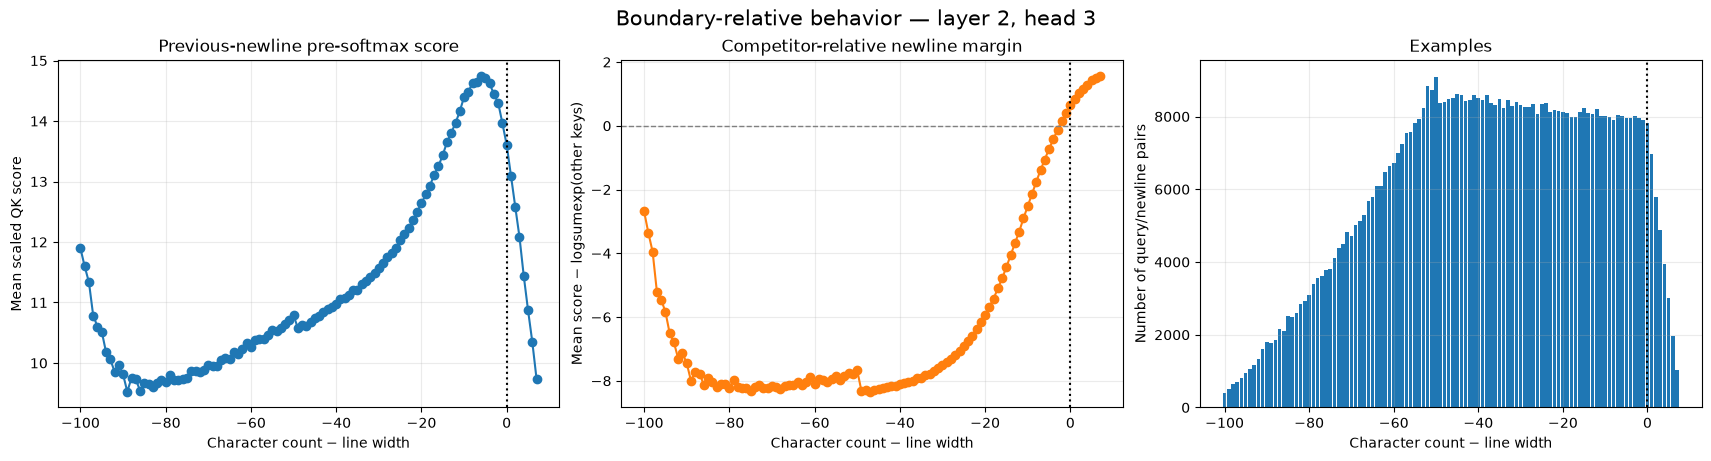

In [6]:
delta_observed = examples_by_delta > 0
plot_delta = DELTA_VALUES[delta_observed]
delta_table = pd.DataFrame({
    "count_minus_width": plot_delta,
    "mean_newline_score": mean_score_by_delta[delta_observed],
    "mean_competitor_margin": mean_margin_by_delta[delta_observed],
    "n_examples": examples_by_delta[delta_observed],
}).set_index("count_minus_width")
display(delta_table)
print("Boundary window:")
display(delta_table.loc[-10:7])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
axes[0].plot(plot_delta, mean_score_by_delta[delta_observed], marker="o")
axes[0].set_title("Previous-newline pre-softmax score")
axes[0].set_ylabel("Mean scaled QK score")

axes[1].plot(
    plot_delta, mean_margin_by_delta[delta_observed], marker="o", color="tab:orange"
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Competitor-relative newline margin")
axes[1].set_ylabel("Mean score − logsumexp(other keys)")

axes[2].bar(plot_delta, examples_by_delta[delta_observed], width=0.85)
axes[2].set_title("Examples")
axes[2].set_ylabel("Number of query/newline pairs")

for ax in axes:
    ax.axvline(0, color="black", linestyle=":", linewidth=1.5)
    ax.set_xlabel("Character count − line width")
    ax.grid(alpha=0.25)
fig.suptitle(
    f"Boundary-relative behavior — layer {LAYER}, head {HEAD}", fontsize=15
)
plt.show()